# Explicabilidad con LIME y SHAP en la predicción de rotación laboral

## Autores

**Juan Pablo Bolta** — Máster en Inteligencia Artificial, Facultad de Informática, UCM. Curso 2025/26.

## Resumen

La rotación laboral involuntaria es uno de los costes ocultos más relevantes para las organizaciones. En este capítulo se construye un modelo de clasificación sobre el dataset IBM HR Analytics Employee Attrition (1.470 empleados, 35 variables) para predecir qué empleados abandonarán la empresa. Sobre este modelo se aplican las técnicas de explicabilidad **SHAP** (*SHapley Additive exPlanations*) y **LIME** (*Local Interpretable Model-agnostic Explanations*) con el doble objetivo de entender qué factores impulsan la rotación a nivel global y de justificar predicciones individuales. El análisis revela que las variables con mayor impacto son el trabajo en horas extra, el salario mensual y el nivel de satisfacción laboral. La comparación entre LIME y SHAP muestra diferencias relevantes en estabilidad y completitud que condicionan su uso en producción. El capítulo concluye con una reflexión sobre las implicaciones éticas de desplegar este tipo de modelos en entornos de recursos humanos.

## Introducción

Perder a un empleado cuesta, según distintos estudios, entre el 50% y el 200% de su salario anual si se tienen en cuenta los costes de reclutamiento, formación e integración del sustituto, así como la pérdida de conocimiento acumulado. La analítica de recursos humanos (*People Analytics*) lleva años intentando anticipar este problema con modelos predictivos, pero la adopción real en las empresas ha chocado siempre con la misma barrera: **¿por qué predice esto el modelo?**

Un mánager de RRHH no tomará decisiones basadas en una probabilidad salida de una caja negra. Para que el modelo sea útil, sus predicciones deben ir acompañadas de explicaciones comprensibles, auditables y accionables. Aquí es donde entra la **Inteligencia Artificial Explicable (XAI)**.

Este capítulo aborda el problema de la rotación laboral como caso de estudio de XAI aplicada. Los objetivos concretos son. \1
1. Entrenar un modelo de predicción de *attrition* sobre datos reales de RRHH.
2. Aplicar **SHAP** para obtener una visión global de los factores que el modelo considera importantes, así como explicaciones locales para decisiones individuales.
3. Aplicar **LIME** para obtener explicaciones locales en formato de reglas interpretables.
4. **Comparar** ambas técnicas: qué explican, cómo difieren y cuándo conviene usar cada una.
5. Reflexionar sobre la **equidad y ética** de usar estos modelos en decisiones de RRHH.



### Dependencias

Las librerías necesarias están listadas en `requirements.txt`. Para instalar el entorno. \1
```bash
pip install -r requirements.txt
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)

import shap
import lime
import lime.lime_tabular

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
shap.initjs()

RANDOM_STATE = 42

## Datos

### Descripción del dataset

El dataset utilizado es el **IBM HR Analytics Employee Attrition**, un conjunto de datos ficticio pero realista creado por IBM para demostrar sus herramientas de analítica de personas. Está disponible públicamente en Kaggle.

| Característica | Detalle |
|---|---|
| Registros | 1.470 empleados |
| Variables | 35 (numéricas y categóricas) |
| Variable objetivo | `Attrition` — si el empleado abandonó la empresa (Yes) o no (No) |
| Desbalance de clases | ~84% permanecen / ~16% abandonan |

Las variables cubren cuatro dimensiones. \1- **Demográficas**: edad, género, estado civil, nivel educativo.
- **Laborales**: departamento, rol, nivel jerárquico, años en la empresa.
- **Económicas**: salario mensual, porcentaje de subida salarial, opciones sobre acciones.
- **Satisfacción**: satisfacción con el trabajo, con el entorno, con las relaciones, balance vida-trabajo.

In [2]:
df_raw = pd.read_csv('datos/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f'Dataset cargado: {df_raw.shape[0]} registros, {df_raw.shape[1]} variables')
display(df_raw.head(3))

Dataset cargado: 1470 registros, 35 variables


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


### Exploración inicial

Antes de modelar, se analiza la distribución de la variable objetivo y los patrones de las variables más relevantes.

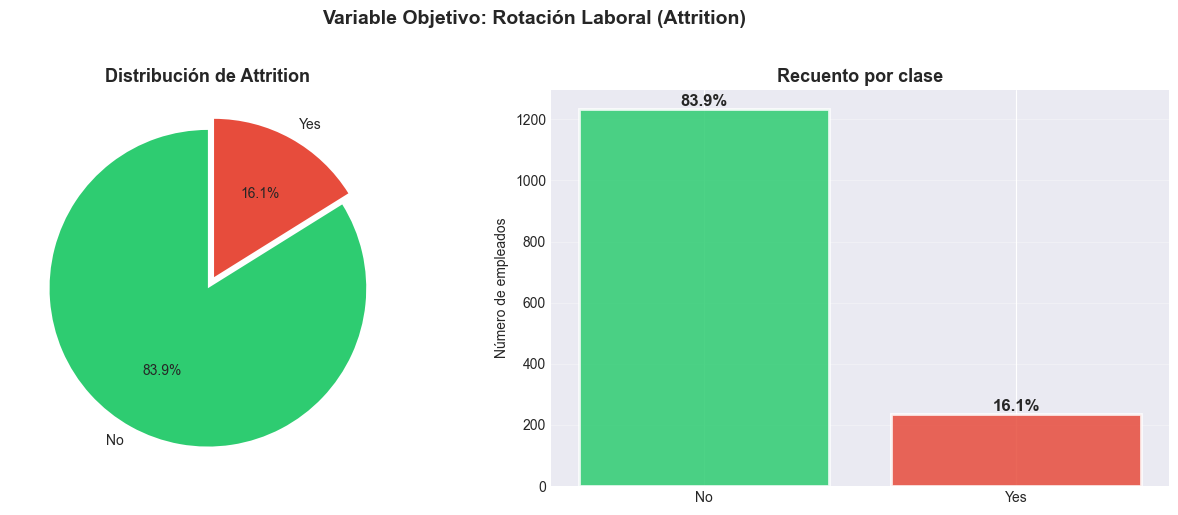

El dataset está desbalanceado: solo el 16.1% de los empleados abandona.
Se usará class_weight="balanced" en los modelos para compensarlo.


In [3]:
# Distribución del target
attrition_counts = df_raw['Attrition'].value_counts()
attrition_pct    = df_raw['Attrition'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(
    attrition_counts.values,
    labels=attrition_counts.index,
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90, explode=(0, 0.08)
)
axes[0].set_title('Distribución de Attrition', fontsize=13, fontweight='bold')

bars = axes[1].bar(attrition_counts.index, attrition_counts.values,
                   color=['#2ecc71', '#e74c3c'], alpha=0.85, edgecolor='white', linewidth=2)
for bar, pct in zip(bars, attrition_pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{pct:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Número de empleados')
axes[1].set_title('Recuento por clase', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Variable Objetivo: Rotación Laboral (Attrition)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'El dataset está desbalanceado: solo el {attrition_pct["Yes"]:.1f}% de los empleados abandona.')
print('Se usará class_weight="balanced" en los modelos para compensarlo.')

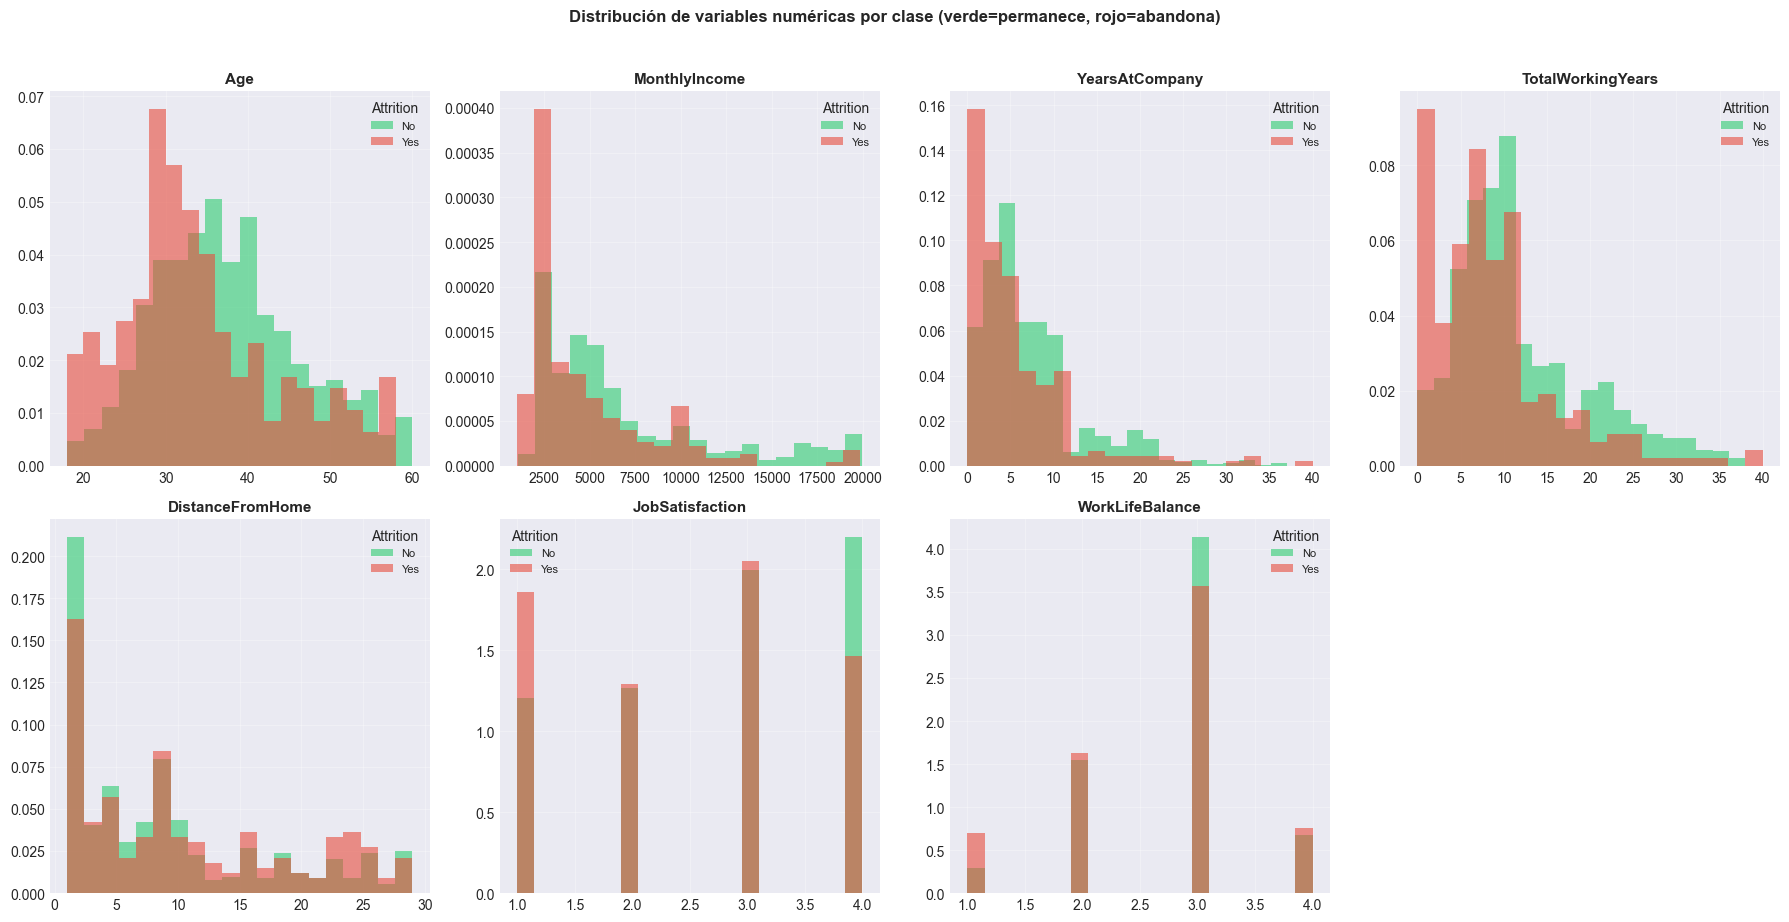

In [4]:
# Distribución de variables numéricas clave por clase
num_features = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears',
                'DistanceFromHome', 'JobSatisfaction', 'WorkLifeBalance']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
        subset = df_raw[df_raw['Attrition'] == label][feat]
        axes[i].hist(subset, bins=20, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].legend(title='Attrition', fontsize=8)
    axes[i].grid(True, alpha=0.3)

axes[-1].axis('off')
plt.suptitle('Distribución de variables numéricas por clase (verde=permanece, rojo=abandona)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

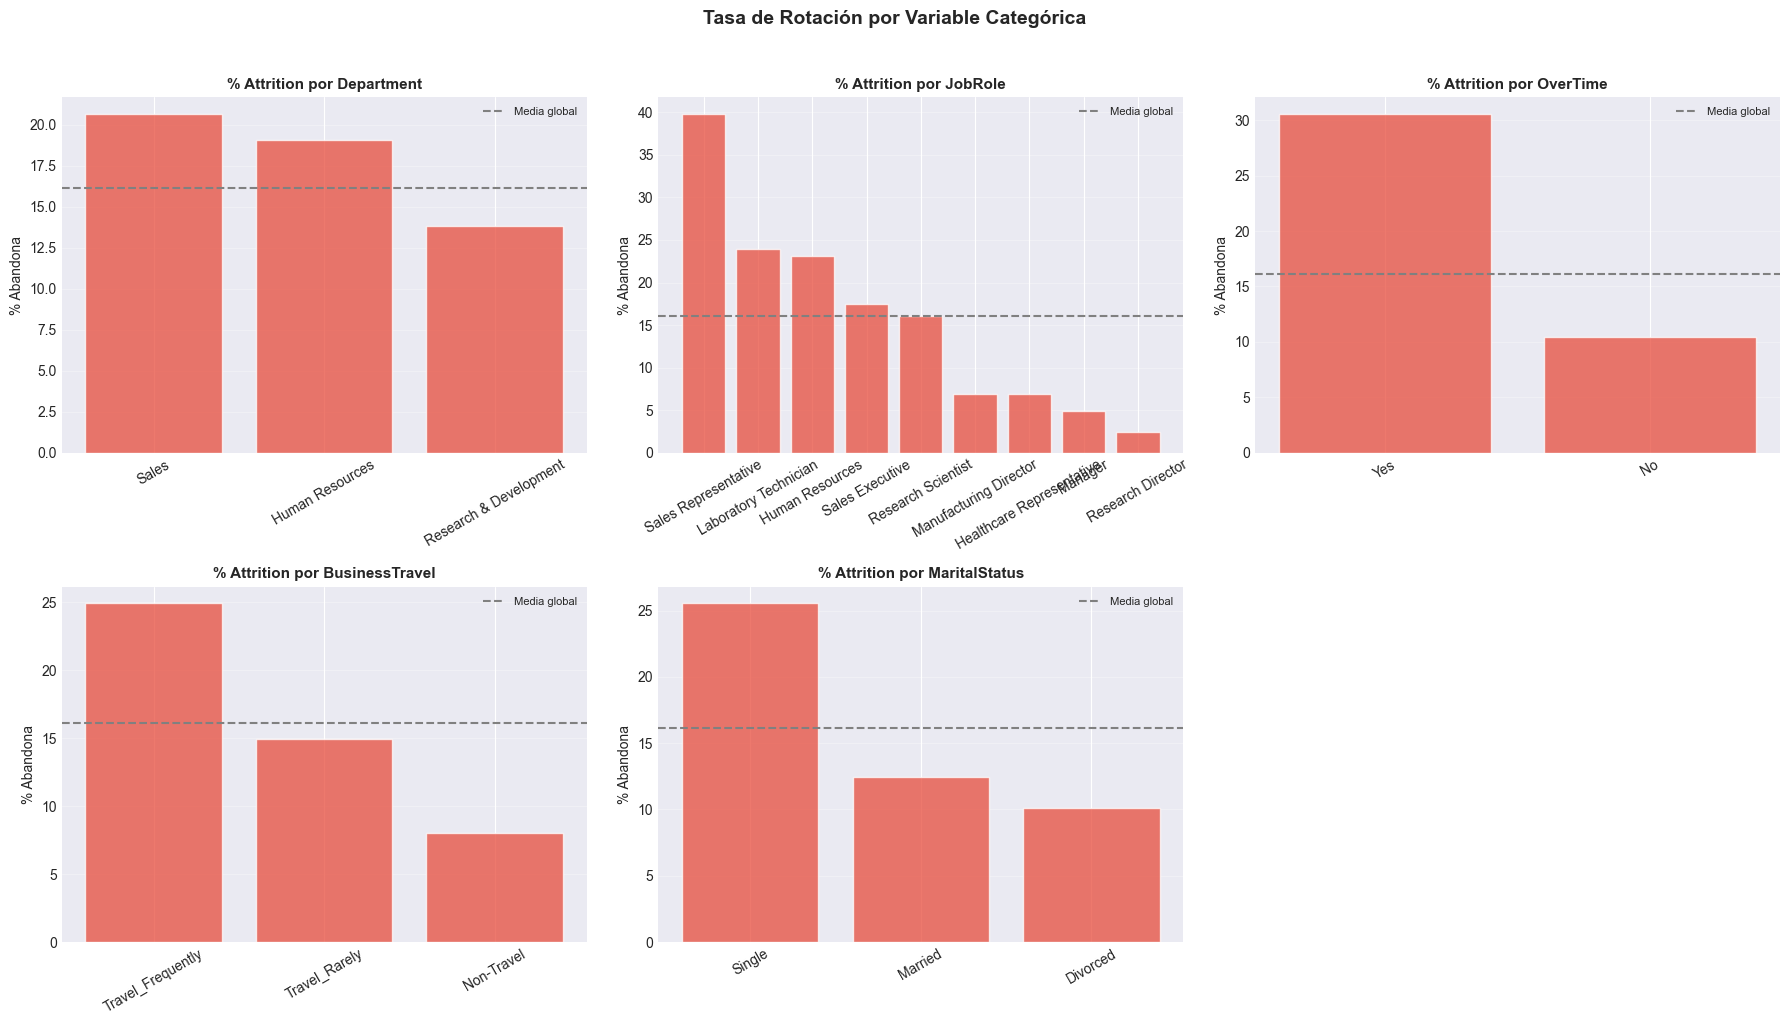

Patrones principales observados en la exploración:
  - Los empleados con OverTime=Yes tienen una tasa de abandono muy superior a la media.
  - Sales Representatives y Laboratory Technicians son los roles con mayor rotación.
  - Los empleados solteros (Single) presentan mayor tasa de abandono que casados o divorciados.


In [5]:
# Tasa de rotación por variables categóricas
cat_features = ['Department', 'JobRole', 'OverTime', 'BusinessTravel', 'MaritalStatus']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
media_global = df_raw['Attrition'].eq('Yes').mean() * 100

for i, feat in enumerate(cat_features):
    pct = df_raw.groupby(feat)['Attrition'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values(ascending=False)
    axes[i].bar(pct.index, pct.values, color='#e74c3c', alpha=0.75, edgecolor='white')
    axes[i].set_title(f'% Attrition por {feat}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('% Abandona')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(y=media_global, color='gray', linestyle='--', linewidth=1.5, label='Media global')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3, axis='y')

axes[-1].axis('off')
plt.suptitle('Tasa de Rotación por Variable Categórica', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Patrones principales observados en la exploración:')
print('  - Los empleados con OverTime=Yes tienen una tasa de abandono muy superior a la media.')
print('  - Sales Representatives y Laboratory Technicians son los roles con mayor rotación.')
print('  - Los empleados solteros (Single) presentan mayor tasa de abandono que casados o divorciados.')

### Preprocesamiento

Se aplican los siguientes pasos antes del modelado. \1
1. **Eliminación de columnas constantes** — `EmployeeCount`, `Over18` y `StandardHours` tienen el mismo valor para todos los registros, por lo que no aportan información.
2. **Eliminación del identificador** — `EmployeeNumber` es un ID sin valor predictivo.
3. **Codificación de variables categóricas** con `LabelEncoder`.
4. **Codificación del target** a binario (1 = abandona, 0 = permanece).
5. **División train/test estratificada** (80/20) respetando el desbalance de clases.
6. **Escalado** de features para el modelo de regresión logística.

In [6]:
df = df_raw.copy()

df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], inplace=True)
df['Attrition'] = (df['Attrition'] == 'Yes').astype(int)

cat_cols = df.select_dtypes(include='object').columns.tolist()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

feature_names = X_train.columns.tolist()

print(f'Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras')
print(f'Variables predictoras: {len(feature_names)}')
print(f'Tasa de rotación en test: {y_test.mean()*100:.1f}%')

Train: 1176 muestras | Test: 294 muestras
Variables predictoras: 30
Tasa de rotación en test: 16.0%


## Modelo(s)

Se entrenan tres modelos de naturaleza distinta para evaluar si las explicaciones XAI son consistentes entre tipos de modelo. \1
| Modelo | Naturaleza | Interpretable por sí mismo |
|---|---|---|
| Logistic Regression | Lineal | Sí (coeficientes directos) |
| Random Forest | Ensemble de árboles | Parcialmente (Gini importance) |
| Gradient Boosting | Ensemble secuencial | No |

El parámetro `class_weight='balanced'` (disponible en LR y RF) corrige el desbalance de clases asignando mayor peso a la clase minoritaria durante el entrenamiento. Para Gradient Boosting se aplica el mismo efecto mediante submuestreo implícito.

El modelo principal para las explicaciones XAI será **Random Forest**, que ofrece buen rendimiento y es compatible con `TreeExplainer` de SHAP, lo que hace el cálculo de valores SHAP muy eficiente.

In [7]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)

gb = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05, random_state=RANDOM_STATE
)
gb.fit(X_train, y_train)

models = {
    'Logistic Regression': (lr, X_test_scaled),
    'Random Forest':       (rf, X_test),
    'Gradient Boosting':   (gb, X_test)
}

print(f'{"Modelo":<25} {"Accuracy":>10} {"ROC-AUC":>10}')
print('-' * 48)
for name, (model, X_eval) in models.items():
    acc = model.score(X_eval, y_test)
    auc = roc_auc_score(y_test, model.predict_proba(X_eval)[:, 1])
    print(f'{name:<25} {acc:>10.3f} {auc:>10.3f}')

Modelo                      Accuracy    ROC-AUC
------------------------------------------------
Logistic Regression            0.752      0.807
Random Forest                  0.827      0.780
Gradient Boosting              0.837      0.789


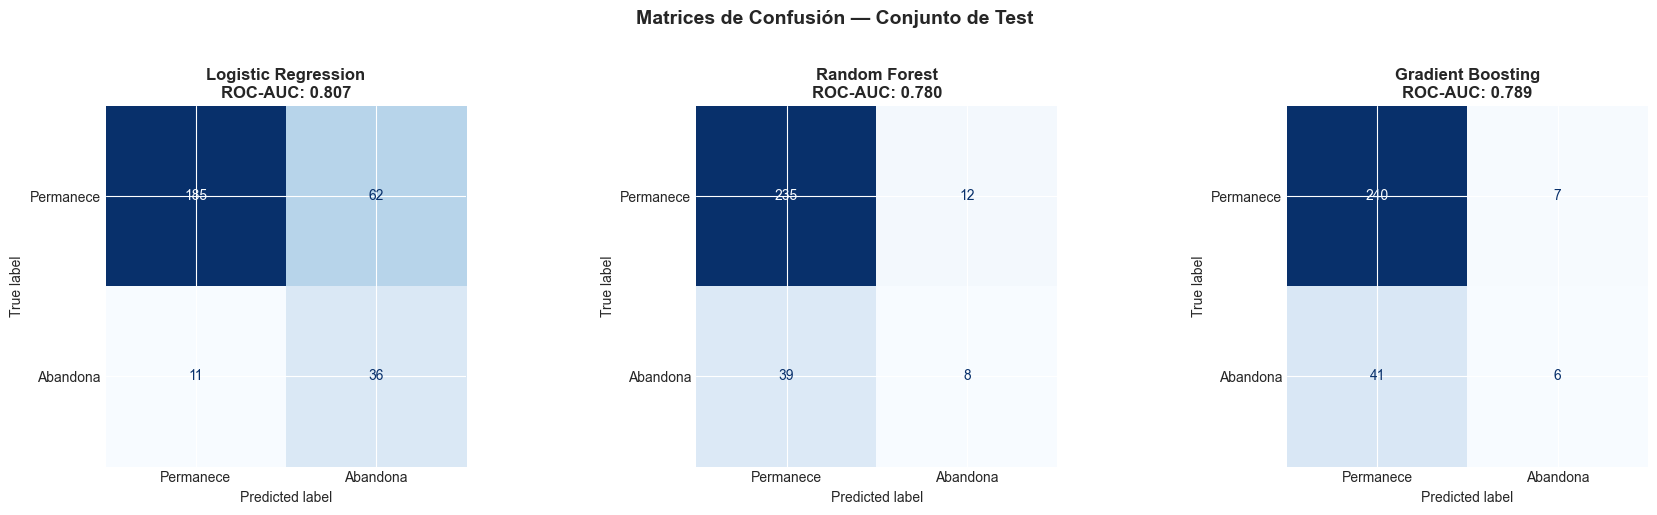

Random Forest y Gradient Boosting obtienen el mejor ROC-AUC.
Se usará Random Forest como modelo principal para las explicaciones.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, (model, X_eval)) in zip(axes, models.items()):
    cm   = confusion_matrix(y_test, model.predict(X_eval))
    disp = ConfusionMatrixDisplay(cm, display_labels=['Permanece', 'Abandona'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    auc = roc_auc_score(y_test, model.predict_proba(X_eval)[:, 1])
    ax.set_title(f'{name}\nROC-AUC: {auc:.3f}', fontsize=12, fontweight='bold')

plt.suptitle('Matrices de Confusión — Conjunto de Test', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Random Forest y Gradient Boosting obtienen el mejor ROC-AUC.')
print('Se usará Random Forest como modelo principal para las explicaciones.')

## Explicaciones

Las técnicas de explicabilidad se dividen en dos planos. \1
- **Global**: qué variables son importantes para el modelo en general.
- **Local**: por qué el modelo predice algo concreto para un empleado específico.

Aplicamos **SHAP** en ambos planos y **LIME** en el local, comparando los resultados.

### SHAP — Explicabilidad Global

**SHAP** (*SHapley Additive exPlanations*, Lundberg & Lee, 2017) fundamenta cada explicación en la teoría de juegos de Shapley. Para cada predicción, el valor SHAP de una variable representa su contribución marginal promediada sobre todas las posibles coaliciones de variables. Formalmente. \1
$$f(x) = \phi_0 + \sum_{i=1}^{M} \phi_i$$

donde $\phi_0$ es el valor base (predicción media del modelo) y $\phi_i$ es la contribución de la variable $i$. Esta propiedad de **completitud** garantiza que los valores SHAP sumen exactamente la diferencia entre la predicción individual y la media.

Para obtener importancia global se agrega el valor absoluto medio de los SHAP de todas las instancias.

In [9]:
explainer_rf  = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test)

# Extraer clase 1 (Attrition=Yes) sea cual sea el formato
if isinstance(shap_values_rf, list):
    shap_vals = shap_values_rf[1]
elif hasattr(shap_values_rf, 'ndim') and shap_values_rf.ndim == 3:
    shap_vals = shap_values_rf[:, :, 1]
else:
    shap_vals = shap_values_rf

ev = explainer_rf.expected_value
base_val = float(ev[1]) if hasattr(ev, '__len__') else float(ev)

print(f'Valores SHAP calculados: {shap_vals.shape[0]} instancias × {shap_vals.shape[1]} variables')
print(f'Valor base del modelo (predicción media): {base_val:.4f}')

Valores SHAP calculados: 294 instancias × 30 variables
Valor base del modelo (predicción media): 0.5022


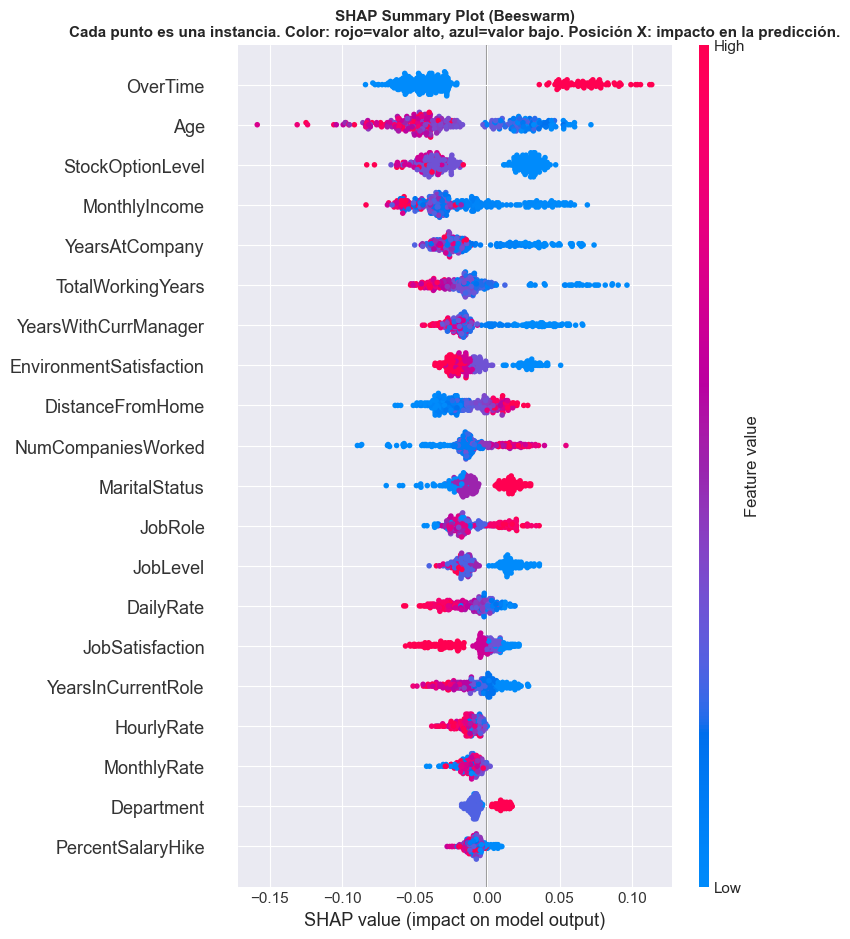

Lectura del gráfico:
  - OverTime alto (rojo) desplaza el punto a la derecha → AUMENTA la probabilidad de abandono.
  - MonthlyIncome alto (rojo) desplaza el punto a la izquierda → DISMINUYE la probabilidad.
  - JobLevel alto → DISMINUYE la probabilidad de abandono.


In [10]:
# Beeswarm — importancia global con dirección del efecto
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_vals, X_test, feature_names=feature_names, max_display=20, show=False)
plt.title(
    'SHAP Summary Plot (Beeswarm)\n'
    'Cada punto es una instancia. Color: rojo=valor alto, azul=valor bajo. Posición X: impacto en la predicción.',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

print('Lectura del gráfico:')
print('  - OverTime alto (rojo) desplaza el punto a la derecha → AUMENTA la probabilidad de abandono.')
print('  - MonthlyIncome alto (rojo) desplaza el punto a la izquierda → DISMINUYE la probabilidad.')
print('  - JobLevel alto → DISMINUYE la probabilidad de abandono.')

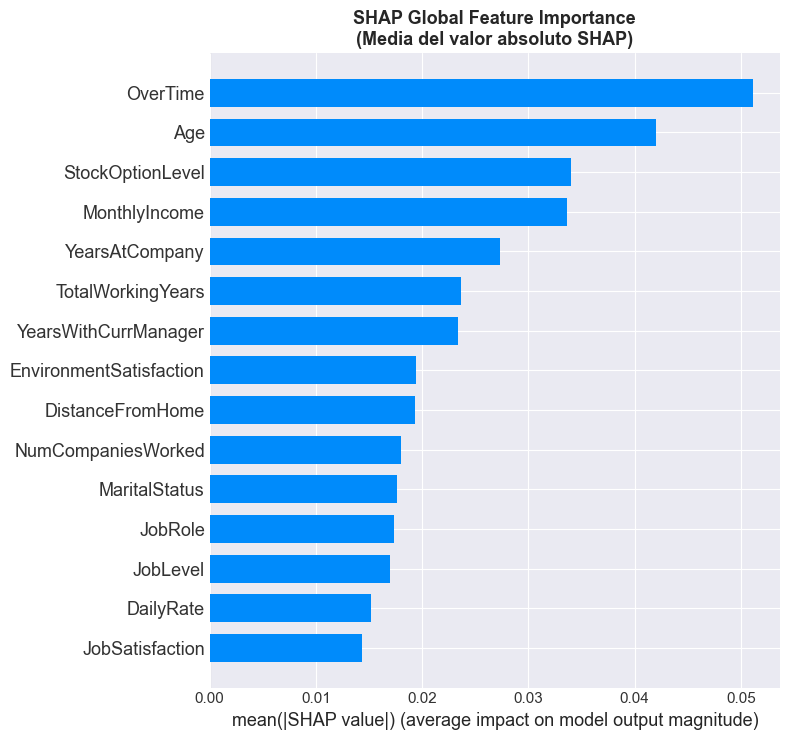


Top-10 variables por importancia SHAP:
OverTime                   0.051119
Age                        0.041992
StockOptionLevel           0.034038
MonthlyIncome              0.033670
YearsAtCompany             0.027340
TotalWorkingYears          0.023641
YearsWithCurrManager       0.023338
EnvironmentSatisfaction    0.019420
DistanceFromHome           0.019355
NumCompaniesWorked         0.018018


In [12]:
# Bar plot — ranking de importancia global
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_test, feature_names=feature_names,
                  plot_type='bar', max_display=15, show=False)
plt.title('SHAP Global Feature Importance\n(Media del valor absoluto SHAP)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

mean_abs_shap = pd.Series(
    np.abs(shap_vals).mean(axis=0), index=feature_names
).sort_values(ascending=False)

print('\nTop-10 variables por importancia SHAP:')
print(mean_abs_shap.head(10).to_string())

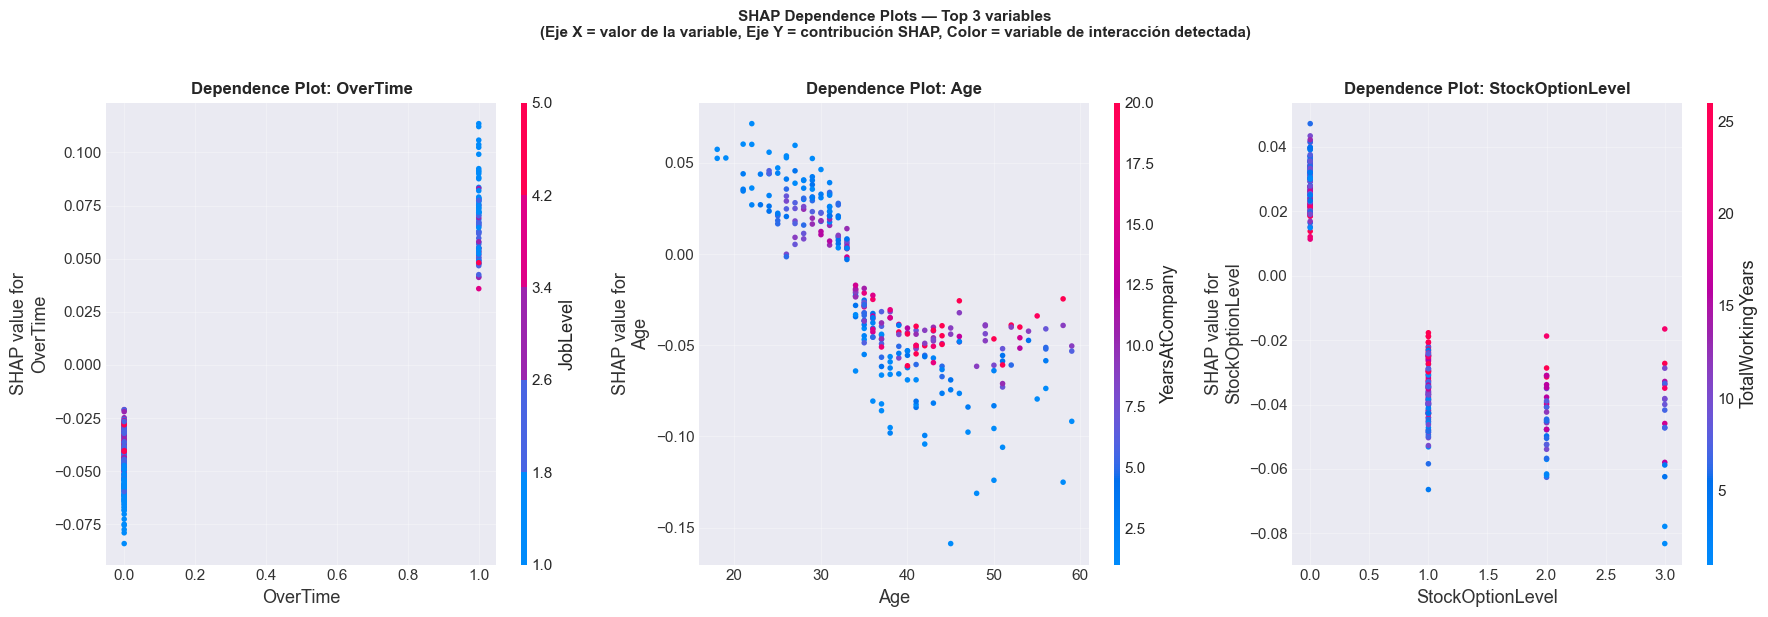

In [13]:
# Dependence plots — efecto marginal de las 3 variables más importantes
top3 = mean_abs_shap.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, feat in zip(axes, top3):
    shap.dependence_plot(feat, shap_vals, X_test, ax=ax, show=False)
    ax.set_title(f'Dependence Plot: {feat}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle(
    'SHAP Dependence Plots — Top 3 variables\n'
    '(Eje X = valor de la variable, Eje Y = contribución SHAP, Color = variable de interacción detectada)',
    fontsize=11, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

### SHAP — Explicabilidad Local

El mismo marco teórico que permite la visión global sirve para explicar predicciones individuales. El *waterfall plot* muestra, para un empleado concreto, cómo cada variable empuja la predicción por encima o por debajo del valor base. Se comparan dos perfiles opuestos: el empleado con mayor probabilidad de abandono predicha y el de menor.

In [14]:
proba_test    = rf.predict_proba(X_test)[:, 1]
idx_high_risk = int(np.argmax(proba_test))
idx_low_risk  = int(np.argmin(proba_test))

emp_high = X_test.iloc[idx_high_risk]
emp_low  = X_test.iloc[idx_low_risk]

vars_clave = ['Age', 'MonthlyIncome', 'OverTime', 'JobSatisfaction',
              'YearsAtCompany', 'WorkLifeBalance', 'JobLevel']

print('=== Perfil del empleado de MAYOR riesgo ===')
print(f'P(abandono) = {proba_test[idx_high_risk]:.3f} | Real: {"Abandona" if y_test.iloc[idx_high_risk]==1 else "No abandona"}')
print(emp_high[vars_clave].to_string())

print('\n=== Perfil del empleado de MENOR riesgo ===')
print(f'P(abandono) = {proba_test[idx_low_risk]:.3f} | Real: {"Abandona" if y_test.iloc[idx_low_risk]==1 else "No abandona"}')
print(emp_low[vars_clave].to_string())

=== Perfil del empleado de MAYOR riesgo ===
P(abandono) = 0.926 | Real: Abandona
Age                  19
MonthlyIncome      2121
OverTime              1
JobSatisfaction       2
YearsAtCompany        1
WorkLifeBalance       4
JobLevel              1

=== Perfil del empleado de MENOR riesgo ===
P(abandono) = 0.045 | Real: No abandona
Age                   40
MonthlyIncome      19436
OverTime               0
JobSatisfaction        3
YearsAtCompany        21
WorkLifeBalance        3
JobLevel               5


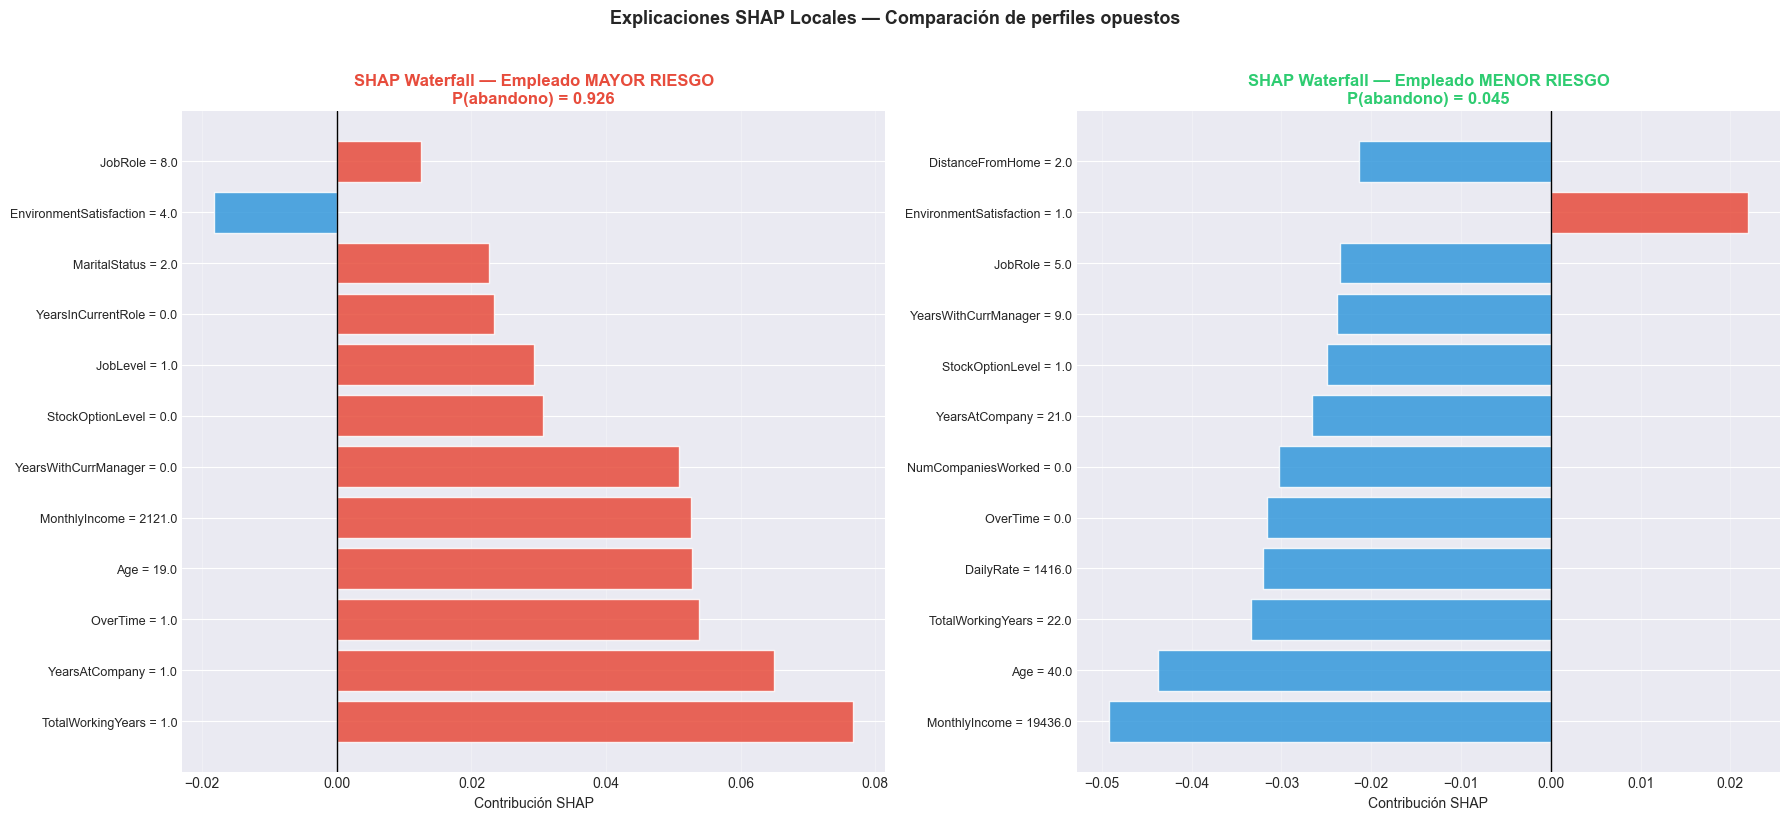

Rojo = variable que AUMENTA la probabilidad de abandono para este empleado.
Azul  = variable que DISMINUYE la probabilidad de abandono para este empleado.


In [15]:
sv_high = shap_vals[idx_high_risk]
sv_low  = shap_vals[idx_low_risk]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, sv, emp, label, color in [
    (axes[0], sv_high, emp_high, 'MAYOR RIESGO', '#e74c3c'),
    (axes[1], sv_low,  emp_low,  'MENOR RIESGO', '#2ecc71')
]:
    order      = np.argsort(np.abs(sv))[::-1][:12]
    feats      = [feature_names[i] for i in order]
    values     = sv[order]
    feat_vals  = emp.iloc[order].values
    bar_colors = ['#e74c3c' if v > 0 else '#3498db' for v in values]

    ax.barh(range(len(feats)), values, color=bar_colors, alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(feats)))
    ax.set_yticklabels([f'{f} = {fv:.1f}' for f, fv in zip(feats, feat_vals)], fontsize=9)
    ax.axvline(x=0, color='black', linewidth=1)
    ax.set_xlabel('Contribución SHAP')
    ax.set_title(
        f'SHAP Waterfall — Empleado {label}\n'
        f'P(abandono) = {rf.predict_proba(emp.values.reshape(1,-1))[0,1]:.3f}',
        fontsize=12, fontweight='bold', color=color
    )
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Explicaciones SHAP Locales — Comparación de perfiles opuestos',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Rojo = variable que AUMENTA la probabilidad de abandono para este empleado.')
print('Azul  = variable que DISMINUYE la probabilidad de abandono para este empleado.')

### LIME — Explicabilidad Local

**LIME** (*Local Interpretable Model-agnostic Explanations*, Ribeiro et al., 2016) aborda la explicabilidad local desde un ángulo distinto: en lugar de calcular contribuciones exactas, **entrena un modelo lineal simple** en el vecindario perturbado de la instancia a explicar. Los coeficientes de ese modelo lineal se presentan como la explicación.

El algoritmo en tres pasos. \11. **Perturbación**: genera instancias aleatorias alrededor del punto a explicar.
2. **Ponderación**: asigna mayor peso a las instancias más cercanas al punto original.
3. **Modelo local**: ajusta una regresión lineal penalizada sobre el vecindario ponderado.

El resultado son reglas del tipo `"OverTime <= 0.5"` con un peso positivo o negativo, que indican en qué dirección influye cada condición sobre la predicción local.

In [16]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=['Permanece', 'Abandona'],
    mode='classification',
    discretize_continuous=True,
    random_state=RANDOM_STATE
)
print('LIME Explainer configurado.')

LIME Explainer configurado.


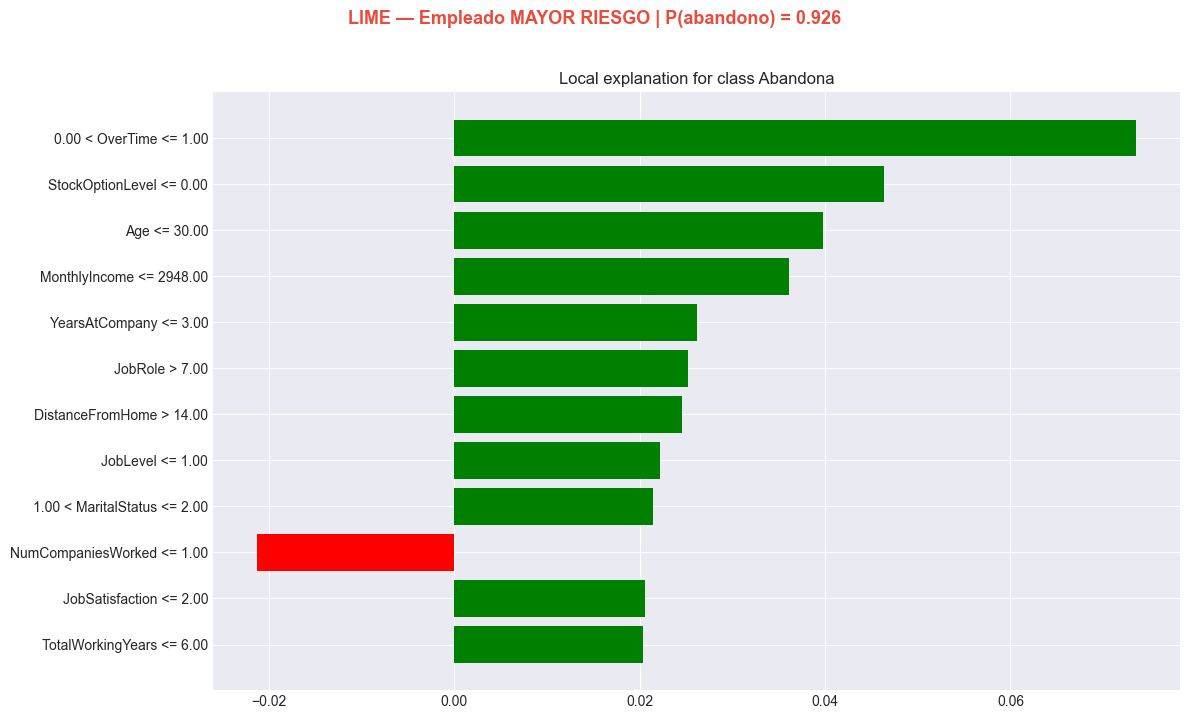

Reglas LIME generadas:
  0.00 < OverTime <= 1.00                       peso=+0.0736  → AUMENTA el riesgo
  StockOptionLevel <= 0.00                      peso=+0.0464  → AUMENTA el riesgo
  Age <= 30.00                                  peso=+0.0398  → AUMENTA el riesgo
  MonthlyIncome <= 2948.00                      peso=+0.0361  → AUMENTA el riesgo
  YearsAtCompany <= 3.00                        peso=+0.0262  → AUMENTA el riesgo
  JobRole > 7.00                                peso=+0.0252  → AUMENTA el riesgo
  DistanceFromHome > 14.00                      peso=+0.0246  → AUMENTA el riesgo
  JobLevel <= 1.00                              peso=+0.0222  → AUMENTA el riesgo
  1.00 < MaritalStatus <= 2.00                  peso=+0.0215  → AUMENTA el riesgo
  NumCompaniesWorked <= 1.00                    peso=-0.0213  → DISMINUYE el riesgo
  JobSatisfaction <= 2.00                       peso=+0.0205  → AUMENTA el riesgo
  TotalWorkingYears <= 6.00                     peso=+0.0204  → AUMENTA e

In [17]:
lime_exp_high = lime_explainer.explain_instance(
    data_row=X_test.iloc[idx_high_risk].values,
    predict_fn=rf.predict_proba,
    num_features=12, num_samples=5000
)

fig = lime_exp_high.as_pyplot_figure(label=1)
fig.set_size_inches(12, 7)
fig.suptitle(
    f'LIME — Empleado MAYOR RIESGO | P(abandono) = {proba_test[idx_high_risk]:.3f}',
    fontsize=13, fontweight='bold', color='#e74c3c', y=1.02
)
plt.tight_layout()
plt.show()

print('Reglas LIME generadas:')
for feat, weight in lime_exp_high.as_list(label=1):
    signo = 'AUMENTA' if weight > 0 else 'DISMINUYE'
    print(f'  {feat:<45} peso={weight:+.4f}  → {signo} el riesgo')

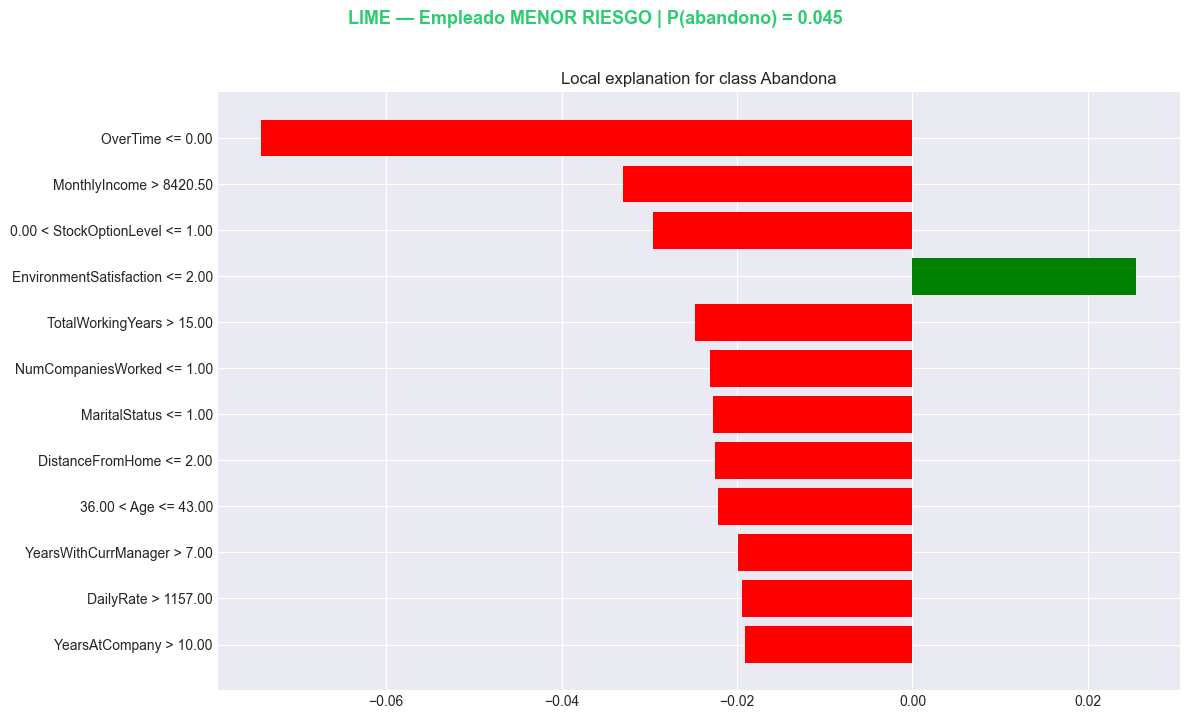

In [18]:
lime_exp_low = lime_explainer.explain_instance(
    data_row=X_test.iloc[idx_low_risk].values,
    predict_fn=rf.predict_proba,
    num_features=12, num_samples=5000
)

fig = lime_exp_low.as_pyplot_figure(label=1)
fig.set_size_inches(12, 7)
fig.suptitle(
    f'LIME — Empleado MENOR RIESGO | P(abandono) = {proba_test[idx_low_risk]:.3f}',
    fontsize=13, fontweight='bold', color='#2ecc71', y=1.02
)
plt.tight_layout()
plt.show()

### Comparación LIME vs SHAP

Aunque ambas técnicas buscan el mismo objetivo —explicar una predicción individual— parten de supuestos distintos y producen resultados con propiedades diferentes.

| Dimensión | LIME | SHAP |
|---|---|---|
| Fundamento teórico | Aproximación lineal local | Teoría de juegos de Shapley |
| Completitud | Parcial (`num_features`) | Completa: $\sum \phi_i = f(x) - \phi_0$ |
| Consistencia entre ejecuciones | No garantizada (aleatorio) | Garantizada (determinista con TreeExplainer) |
| Velocidad | Lento (muestreo del vecindario) | Rápido (TreeExplainer es exacto en $O(TLD^2)$) |
| Formato de salida | Reglas discretizadas if-then | Contribuciones continuas por variable |
| Uso global | No directamente | Sí (agregando los valores locales) |

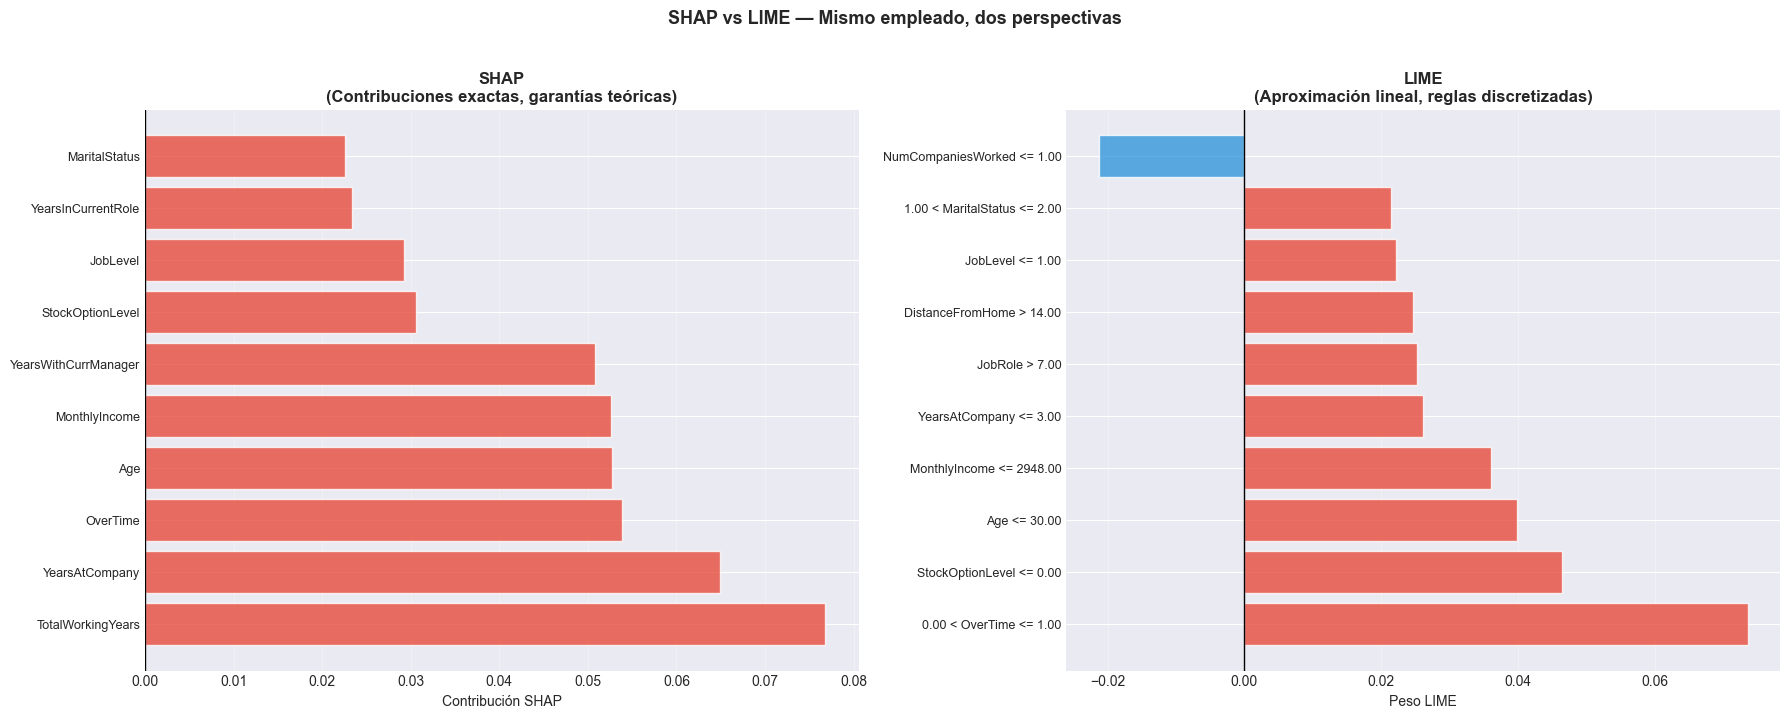

In [19]:
# Comparación visual LIME vs SHAP — empleado de mayor riesgo
shap_for_high = dict(zip(feature_names, sv_high))
top_shap = sorted(shap_for_high, key=lambda k: abs(shap_for_high[k]), reverse=True)[:10]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# SHAP
sv_plot = [shap_for_high[f] for f in top_shap]
axes[0].barh(range(len(top_shap)), sv_plot,
             color=['#e74c3c' if v > 0 else '#3498db' for v in sv_plot],
             alpha=0.8, edgecolor='white')
axes[0].set_yticks(range(len(top_shap)))
axes[0].set_yticklabels(top_shap, fontsize=9)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_xlabel('Contribución SHAP')
axes[0].set_title('SHAP\n(Contribuciones exactas, garantías teóricas)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# LIME
lime_list  = lime_exp_high.as_list(label=1)[:10]
lime_names = [f for f, _ in lime_list]
lime_vals  = [w for _, w in lime_list]
axes[1].barh(range(len(lime_names)), lime_vals,
             color=['#e74c3c' if v > 0 else '#3498db' for v in lime_vals],
             alpha=0.8, edgecolor='white')
axes[1].set_yticks(range(len(lime_names)))
axes[1].set_yticklabels(lime_names, fontsize=9)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Peso LIME')
axes[1].set_title('LIME\n(Aproximación lineal, reglas discretizadas)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('SHAP vs LIME — Mismo empleado, dos perspectivas',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

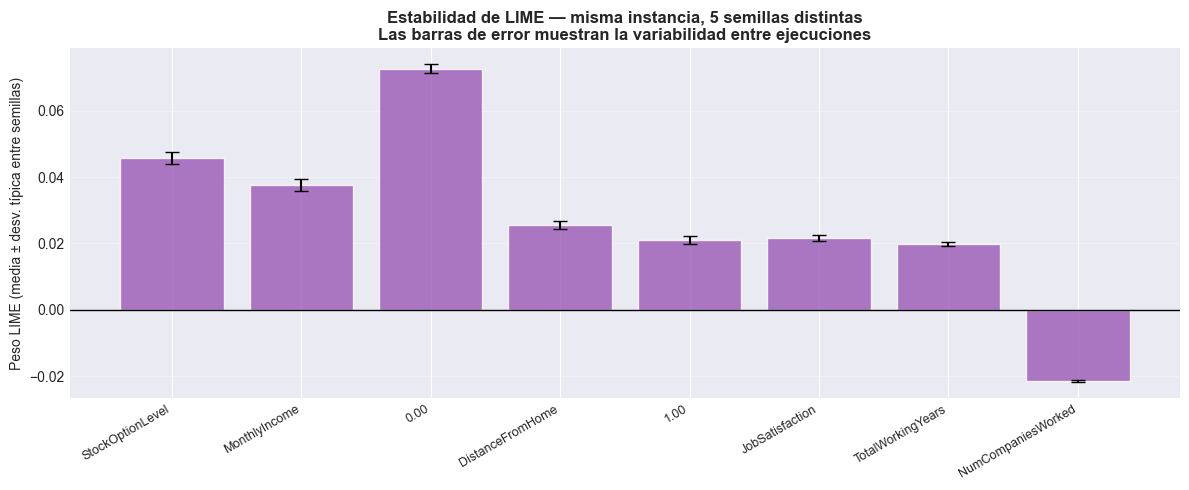

La variabilidad en los pesos LIME entre semillas es una limitación práctica relevante.
SHAP, al usar TreeExplainer exacto, produce siempre el mismo resultado para el mismo modelo.


In [20]:
# Estabilidad de LIME entre semillas distintas
seeds = [0, 1, 42, 123, 999]
pesos_por_semilla = []

for seed in seeds:
    exp = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train.values,
        feature_names=feature_names,
        class_names=['Permanece', 'Abandona'],
        mode='classification',
        discretize_continuous=True,
        random_state=seed
    ).explain_instance(
        data_row=X_test.iloc[idx_high_risk].values,
        predict_fn=rf.predict_proba,
        num_features=12, num_samples=5000
    )
    pesos_por_semilla.append({f.split(' ')[0]: w for f, w in exp.as_list(label=1)})

all_feats = set(k for d in pesos_por_semilla for k in d)
var_data = []
for feat in list(all_feats)[:8]:
    vals = [d.get(feat, np.nan) for d in pesos_por_semilla]
    var_data.append({'Feature': feat, 'Media': np.nanmean(vals), 'Std': np.nanstd(vals)})

var_df = pd.DataFrame(var_data).sort_values('Std', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(var_df)), var_df['Media'].values, yerr=var_df['Std'].values,
       capsize=5, color='#9b59b6', alpha=0.8, edgecolor='white')
ax.set_xticks(range(len(var_df)))
ax.set_xticklabels(var_df['Feature'].values, rotation=30, ha='right', fontsize=9)
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('Peso LIME (media ± desv. típica entre semillas)')
ax.set_title(
    f'Estabilidad de LIME — misma instancia, {len(seeds)} semillas distintas\n'
    'Las barras de error muestran la variabilidad entre ejecuciones',
    fontsize=12, fontweight='bold'
)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('La variabilidad en los pesos LIME entre semillas es una limitación práctica relevante.')
print('SHAP, al usar TreeExplainer exacto, produce siempre el mismo resultado para el mismo modelo.')

### Análisis de Equidad

Desplegar un modelo de predicción de rotación en RRHH exige verificar que no amplifica sesgos existentes en los datos históricos. En particular, variables como género, estado civil o edad no deberían determinar sistemáticamente quién recibe atención preventiva por parte de la empresa.

A continuación se analiza si el modelo asigna riesgos distintos a grupos protegidos.

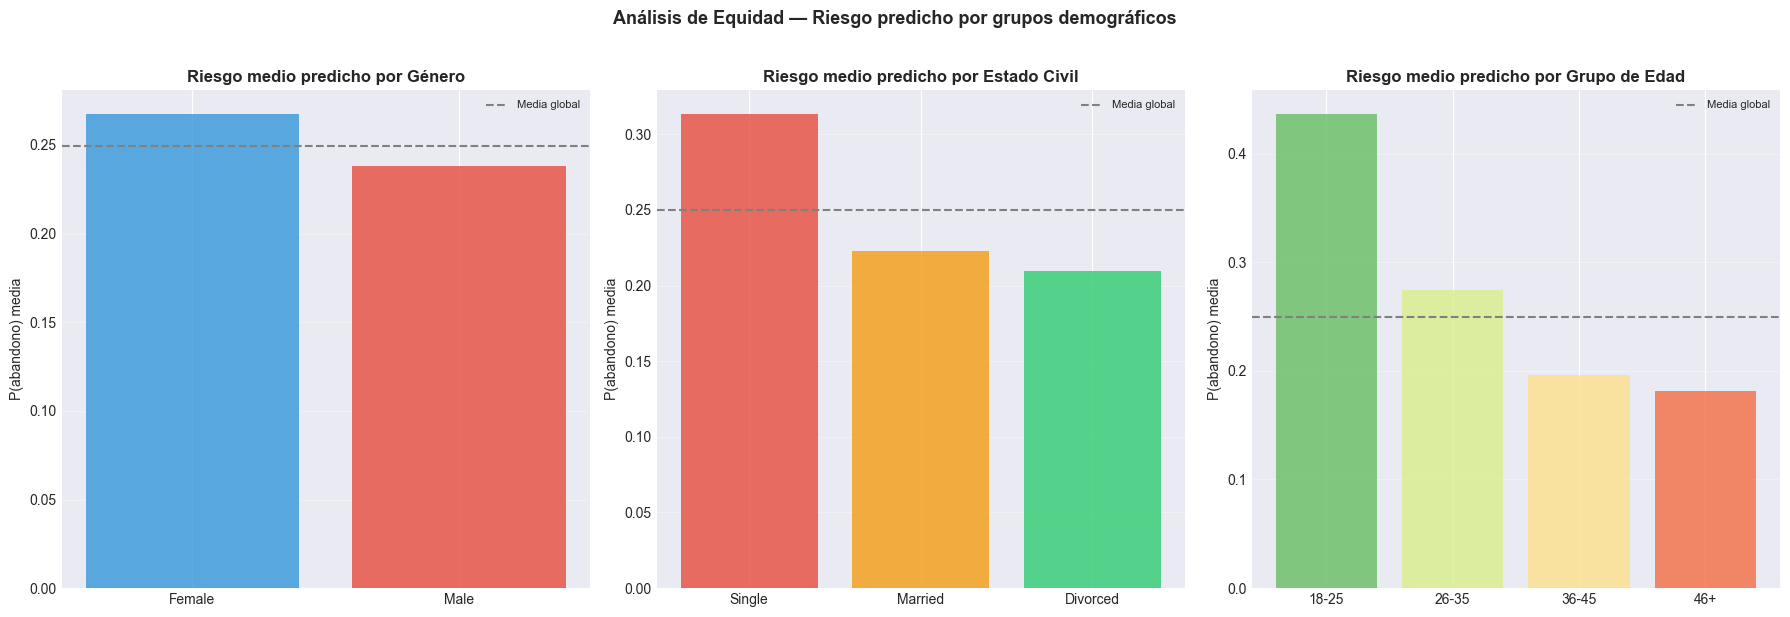

Interpretación:
  - Diferencias entre grupos pueden reflejar patrones reales en los datos históricos o sesgos heredados.
  - Antes de usar el modelo para decisiones de retención, se recomienda auditar con métricas de equidad
    (p.ej. igualdad de oportunidades, paridad demográfica) usando herramientas como Fairlearn.


In [21]:
test_df = X_test.copy()
test_df['y_true']      = y_test.values
test_df['y_pred_prob'] = proba_test

test_df['Gender_dec']        = label_encoders['Gender'].inverse_transform(test_df['Gender'].astype(int))
test_df['MaritalStatus_dec'] = label_encoders['MaritalStatus'].inverse_transform(test_df['MaritalStatus'].astype(int))
test_df['Age_group']         = pd.cut(test_df['Age'], bins=[18,25,35,45,60],
                                       labels=['18-25','26-35','36-45','46+'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
media_pred = proba_test.mean()

for ax, col, title, palette in [
    (axes[0], 'Gender_dec',        'Género',       ['#3498db','#e74c3c']),
    (axes[1], 'MaritalStatus_dec', 'Estado Civil',  ['#e74c3c','#f39c12','#2ecc71']),
    (axes[2], 'Age_group',         'Grupo de Edad', None)
]:
    grupo = test_df.groupby(col, observed=True)['y_pred_prob'].mean().sort_values(ascending=False)
    colors = palette if palette else plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(grupo)))
    ax.bar(grupo.index.astype(str), grupo.values, color=colors, alpha=0.8)
    ax.axhline(media_pred, color='gray', linestyle='--', linewidth=1.5, label='Media global')
    ax.set_title(f'Riesgo medio predicho por {title}', fontsize=12, fontweight='bold')
    ax.set_ylabel('P(abandono) media')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Análisis de Equidad — Riesgo predicho por grupos demográficos',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Interpretación:')
print('  - Diferencias entre grupos pueden reflejar patrones reales en los datos históricos o sesgos heredados.')
print('  - Antes de usar el modelo para decisiones de retención, se recomienda auditar con métricas de equidad')
print('    (p.ej. igualdad de oportunidades, paridad demográfica) usando herramientas como Fairlearn.')

## Conclusiones

Este capítulo ha analizado la predicción de rotación laboral mediante técnicas de XAI con tres resultados principales. \1
**Sobre el problema de negocio.** Los factores que más influyen en la rotación son el trabajo en horas extra (`OverTime`), el salario mensual (`MonthlyIncome`) y el nivel jerárquico (`JobLevel`). Estos hallazgos son coherentes con la literatura de RRHH y permiten traducir el modelo en recomendaciones accionables: reducir el overtime y ajustar las bandas salariales en los perfiles de mayor riesgo son las palancas con mayor impacto potencial.

**Sobre SHAP.** La propiedad de completitud y el respaldo en la teoría de Shapley hacen de SHAP la técnica más robusta para explicaciones técnicas y de auditoría. El uso de `TreeExplainer` es eficiente y determinista. Los *beeswarm plots* y *dependence plots* permiten comunicar tanto importancia como dirección del efecto de forma visual.

**Sobre LIME.** LIME produce explicaciones en formato de reglas que son más intuitivas para audiencias no técnicas. Sin embargo, la dependencia de la semilla aleatoria introduce variabilidad que puede ser problemática en producción: dos ejecuciones con la misma instancia pueden producir rankings de variables distintos. Su uso en decisiones de alto impacto requiere promediar sobre múltiples ejecuciones.

**Sobre ética y equidad.** El análisis de grupos demográficos muestra diferencias en el riesgo predicho entre géneros, estados civiles y franjas de edad. Antes de desplegar este modelo en un entorno real sería imprescindible una auditoría de equidad formal y la exclusión explícita de variables protegidas del proceso de decisión.

**Limitaciones y extensiones.** El dataset es sintético, lo que limita la generalización de los hallazgos. Como extensiones naturales se propone: (1) aplicar métricas de equidad formales con Fairlearn, (2) evaluar la fidelidad de las explicaciones LIME con la métrica de Jaccard sobre múltiples ejecuciones, y (3) explorar Gradient Boosting con SHAP para comparar si los rankings de importancia global son consistentes entre arquitecturas de árbol.

## Referencias

- Biecek, P. & Burzykowski, T. (2021). *Explanatory Model Analysis*. CRC Press. Disponible en: https://ema.drwhy.ai/

- Biecek, P. (Ed.) (2021). *XAI Stories*. Proyecto colaborativo online. Disponible en: https://pbiecek.github.io/xai_stories/

- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems (NeurIPS)*, 30.

- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). "Why should I trust you?": Explaining the predictions of any classifier. *Proceedings of KDD 2016*, 1135–1144.

- IBM HR Analytics Employee Attrition Dataset. Kaggle. https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.